# Phân loại bệnh gan từ tập dữ liệu LPD — Notebook chạy được

**Mục tiêu:** Xây dựng một pipeline tiền xử lý dữ liệu và huấn luyện một mô hình **Random Forest** để phân loại _có bệnh gan_ / _không bệnh gan_.

**Nội dung notebook:**

1. Đọc và quan sát dữ liệu
2. Tiền xử lý (sửa giá trị bất hợp lý, tính/điền các chỉ số dựa trên quan hệ y sinh Albumin/TotalProtein/A_G, điền missing bằng median, winsorization)
3. Mã hóa biến phân loại, chia train/test
4. Huấn luyện Random Forest + cross-validation
5. Báo cáo kết quả: accuracy, precision, recall, f1, ROC-AUC, confusion matrix


In [43]:
import os
import warnings
warnings.filterwarnings('once')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

try:
    from imblearn.over_sampling import SMOTE
    imblearn_available = True
except Exception:
    imblearn_available = False

print('imblearn available:', imblearn_available)


imblearn available: True


In [44]:
df = pd.read_csv("data/train_original.csv", encoding='latin1')
test_df  = pd.read_csv("data/test_original.csv", encoding='latin1')
# Làm sạch tên cột
df.columns = df.columns.str.strip()               
df.columns = df.columns.str.replace('\xa0', ' ')  
df.columns = df.columns.str.replace(' ', '_')

df.columns = df.columns.str.encode('ascii', 'ignore').str.decode('ascii')
df.columns = df.columns.str.replace(r'\xa0', ' ', regex=True) 
df.columns = df.columns.str.strip().str.replace(' ', '_') 

test_df.columns = test_df.columns.str.strip()               
test_df.columns = test_df.columns.str.replace('\xa0', ' ')  
test_df.columns = test_df.columns.str.replace(' ', '_')

test_df.columns = test_df.columns.str.encode('ascii', 'ignore').str.decode('ascii')
test_df.columns = test_df.columns.str.replace(r'\xa0', ' ', regex=True) 
test_df.columns = test_df.columns.str.strip().str.replace(' ', '_') 

print('Kích thước dữ liệu test:', test_df.shape)
print('Kích thước dữ liệu train:', df.shape)
df.head()


Kích thước dữ liệu test: (3874, 11)
Kích thước dữ liệu train: (15494, 11)


,Age_of_the_patient,Gender_of_the_patient,Total_Bilirubin,Direct_Bilirubin,Alkphos_Alkaline_Phosphotase,Sgpt_Alamine_Aminotransferase,Sgot_Aspartate_Aminotransferase,Total_Protiens,ALB_Albumin,A/G_Ratio_Albumin_and_Globulin_Ratio,Result
0,19.0,2.0,2.0,1.1,664.0,52.0,104.0,6.0,2.1,0.53,1
1,30.0,1.0,1.1,0.3,198.0,86.0,150.0,6.3,3.5,1.20,1
2,33.0,2.0,2.4,1.0,340.0,25.0,21.0,8.3,4.5,1.10,1
3,11.0,1.0,8.9,4.0,950.0,33.0,32.0,6.8,3.1,0.80,1
4,50.0,2.0,0.7,0.1,152.0,90.0,21.0,7.1,4.2,1.40,2


In [45]:
print(df.info())

print('\nSố missing theo cột:')
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('\nCác cột số:', numeric_cols)
print(df[numeric_cols].describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15494 entries, 0 to 15493
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age_of_the_patient                    15493 non-null  float64
 1   Gender_of_the_patient                 14862 non-null  float64
 2   Total_Bilirubin                       15045 non-null  float64
 3   Direct_Bilirubin                      15114 non-null  float64
 4   Alkphos_Alkaline_Phosphotase          14937 non-null  float64
 5   Sgpt_Alamine_Aminotransferase         15116 non-null  float64
 6   Sgot_Aspartate_Aminotransferase       15175 non-null  float64
 7   Total_Protiens                        15203 non-null  float64
 8   ALB_Albumin                           15161 non-null  float64
 9   A/G_Ratio_Albumin_and_Globulin_Ratio  15154 non-null  float64
 10  Result                                15494 non-null  int64  
dtypes: float64(10),

In [46]:
data = df.copy()
testData = test_df.copy()
data.columns = [c.strip() for c in data.columns]

label_col = 'Result'
print('Cột nhãn sử dụng:', label_col)

# Đổi tên cột dài → tên ngắn gọn
col_map = {
    'Age_of_the_patient': 'Age',
    'Gender_of_the_patient': 'Sex',
    'Total_Bilirubin': 'Total_Bilirubin',
    'Direct_Bilirubin': 'Direct_Bilirubin',
    'Alkphos_Alkaline_Phosphotase': 'ALP',
    'Sgpt_Alamine_Aminotransferase': 'ALT',
    'Sgot_Aspartate_Aminotransferase': 'AST',
    'Total_Protiens': 'Total_Protein',
    'ALB_Albumin': 'Albumin',
    'A/G_Ratio_Albumin_and_Globulin_Ratio': 'A_G_Ratio'
}
data.rename(columns=col_map, inplace=True)
testData.rename(columns=col_map, inplace=True)

# Kiểm tra dữ liệu bilirubin
bad_direct = data.index[data['Total_Bilirubin'].notnull() & data['Direct_Bilirubin'].notnull() & (data['Direct_Bilirubin'] > data['Total_Bilirubin'])].tolist()+testData.index[testData['Total_Bilirubin'].notnull() & testData['Direct_Bilirubin'].notnull() & (testData['Direct_Bilirubin'] > testData['Total_Bilirubin'])].tolist()

if len(bad_direct) > 0:
    print(f'Có {len(bad_direct)} dòng Direct > Total — sẽ tự điều chỉnh.')
    data.loc[bad_direct, 'Direct_Bilirubin'] = data.loc[bad_direct, 'Total_Bilirubin']

# Thống kê giá trị thiếu
print('\nSố lượng giá trị thiếu theo cột:')
cols = [
    'Age',
    'Sex',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'ALP',
    'ALT',
    'AST',
    'Total_Protein',
    'Albumin',
    'A_G_Ratio'
]
print(data[cols].isnull().sum() + testData[cols].isnull().sum())


Cột nhãn sử dụng: Result
Có 92 dòng Direct > Total — sẽ tự điều chỉnh.

Số lượng giá trị thiếu theo cột:
Age                   1
Sex                 796
Total_Bilirubin     557
Direct_Bilirubin    490
ALP                 694
ALT                 459
AST                 393
Total_Protein       370
Albumin             413
A_G_Ratio           436
dtype: int64


In [ ]:
def fill_ag_albumin_total(df):
    # Công thức: A_G_Ratio = Albumin / (Total_Protein - Albumin)
    mask_ag = df['A_G_Ratio'].isnull() & df['Albumin'].notnull() & df['Total_Protein'].notnull()
    df.loc[mask_ag, 'A_G_Ratio'] = df.loc[mask_ag, 'Albumin'] / (df.loc[mask_ag, 'Total_Protein'] - df.loc[mask_ag, 'Albumin'])

    mask_albumin = df['Albumin'].isnull() & df['A_G_Ratio'].notnull() & df['Total_Protein'].notnull()
    df.loc[mask_albumin, 'Albumin'] = (df.loc[mask_albumin, 'A_G_Ratio'] * df.loc[mask_albumin, 'Total_Protein']) / (1 + df.loc[mask_albumin, 'A_G_Ratio'])

    mask_total = df['Total_Protein'].isnull() & df['Albumin'].notnull() & df['A_G_Ratio'].notnull()
    df.loc[mask_total, 'Total_Protein'] = df.loc[mask_total, 'Albumin'] * (1 + 1.0/df.loc[mask_total, 'A_G_Ratio'])

    return df

data = fill_ag_albumin_total(data)
testData = fill_ag_albumin_total(testData)

after_missing = data[['A_G_Ratio','Albumin','Total_Protein']].isnull().sum() + testData[['A_G_Ratio','Albumin','Total_Protein']].isnull().sum()
print('Missing sau khi điền bằng công thức:', after_missing)

# Sau khi dùng quan hệ, nếu vẫn missing thì điền bằng median (robust với outliers)
for c in ['Age','Total_Bilirubin','Direct_Bilirubin','ALP','ALT','AST',
          'Total_Protein','Albumin','A_G_Ratio', 'Sex']:
    if c in data.columns:
        med = data[c].median()
        data[c] = data[c].fillna(med)
    if c in testData.columns:
        med = testData[c].median()
        testData[c] = testData[c].fillna(med)


print('\nMissing tổng sau điền median/mode:')
print(data.isnull().sum() + testData.isnull().sum())


Missing sau khi điền bằng công thức: A_G_Ratio        131
Albumin          190
Total_Protein    106
dtype: int64

Missing tổng sau điền median/mode:
Age                 0
Sex                 0
Total_Bilirubin     0
Direct_Bilirubin    0
ALP                 0
ALT                 0
AST                 0
Total_Protein       0
Albumin             0
A_G_Ratio           0
Result              0
dtype: int64


In [48]:
# label không được dùng
label_col = 'Result'

# Tạo X_train, y_train 
X_train = data.drop(columns=[label_col])
y_train = data[label_col]

# Tạo X_test, y_test 
X_test = testData.drop(columns=[label_col])
y_test = testData[label_col]


print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)

Kích thước tập Train: (15494, 10)
Kích thước tập Test: (3874, 10)


In [49]:
cols_to_winsor = [
    c for c in [
        'Total_Bilirubin','Direct_Bilirubin','ALP','ALT','AST',
        'Total_Protein','Albumin','A_G_Ratio'
    ] if c in X_train.columns
]

# Lưu ngưỡng từ TRAIN
winsor_limits = {}

for c in cols_to_winsor:
    low = X_train[c].quantile(0.01)
    high = X_train[c].quantile(0.99)
    winsor_limits[c] = (low, high)

    X_train[c] = X_train[c].clip(lower=low, upper=high)
    X_test[c]  = X_test[c].clip(lower=low, upper=high)

print("Hoàn tất winsorization")


Hoàn tất winsorization


In [ ]:
#dùng SMOTE, chỉ áp dụng trên train
use_smote = False
if imblearn_available and use_smote:
    from imblearn.over_sampling import SMOTE

    X_train_sm = X_train.copy()

    # SMOTE
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train_sm, y_train)

    print('After SMOTE, train shape:', X_train_sm.shape)

else:
    X_train_sm, y_train_sm = X_train, y_train


# Chuẩn hóa (standard) trước khi train (không bắt buộc)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm.select_dtypes(include=[np.number]))
X_test_scaled = scaler.transform(X_test.select_dtypes(include=[np.number]))

# Lưu danh sách feature numeric để mapping lại
numeric_features = X_train_sm.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric features used:', numeric_features)


Numeric features used: ['Age', 'Sex', 'Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 'ALT', 'AST', 'Total_Protein', 'Albumin', 'A_G_Ratio']


CV accuracy (5-fold): [0.99548241 0.99806389 0.99677315 0.99645047 0.99548096]
CV accuracy mean: 0.9964501762475286

--- Kết quả trên tập test ---
Accuracy: 0.9958699019101703
Precision: 0.9956678700361011
Recall: 0.998551774076756
F1-score: 0.9971077368040492
ROC-AUC: 0.9999267421689005

Classification report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2762
           2       1.00      0.99      0.99      1112

    accuracy                           1.00      3874
   macro avg       1.00      0.99      0.99      3874
weighted avg       1.00      1.00      1.00      3874

Confusion matrix:
 [[2758    4]
 [  12 1100]]


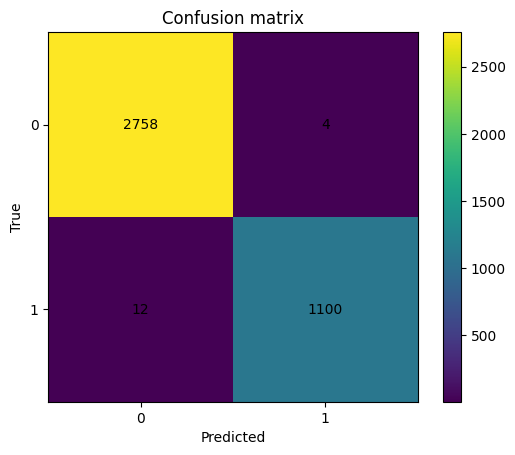

In [51]:
# Huấn luyện Random Forest trên dữ liệu đã chuẩn hóa
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# Cross-validation (Stratified KFold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_scaled, y_train_sm, cv=skf, scoring='accuracy')
print('CV accuracy (5-fold):', cv_scores)
print('CV accuracy mean:', cv_scores.mean())

# Fit trên toàn bộ train rồi đánh giá trên test
rf.fit(X_train_scaled, y_train_sm)

y_pred = rf.predict(X_test_scaled)

y_prob = None
try:
    y_prob = rf.predict_proba(X_test_scaled)[:,1]
except Exception:
    pass

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

print('\n--- Kết quả trên tập test ---')
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)
print('F1-score:', f1)
print('ROC-AUC:', roc)

print('\nClassification report:\n')
print(classification_report(y_test, y_pred, zero_division=0))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

# Vẽ ma trận nhầm lẫn
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0,1])
plt.yticks([0,1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.show()


Top 10 feature theo importance:
ALP                 0.165313
AST                 0.152505
ALT                 0.150772
Total_Bilirubin     0.123349
Total_Protein       0.111950
Albumin             0.107024
A_G_Ratio           0.100298
Direct_Bilirubin    0.083973
Age                 0.004379
Sex                 0.000437
dtype: float64


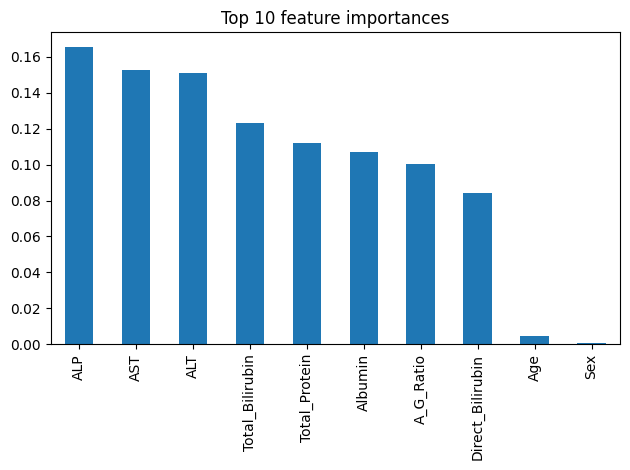

In [52]:
# Giá trị quan trọng của biến (feature importances)
importances = rf.feature_importances_
fi = pd.Series(importances, index=numeric_features).sort_values(ascending=False)
print('Top 10 feature theo importance:')
print(fi.head(10))

# Vẽ biểu đồ nhỏ
plt.figure()
fi.head(10).plot(kind='bar')
plt.title('Top 10 feature importances')
plt.tight_layout()
plt.show()


In [53]:
# Lưu mô hình và scaler để dùng sau này
import joblib
model_path = '/mnt/data/rf_liver_model.joblib'
scaler_path = '/mnt/data/scaler_liver.joblib'
joblib.dump(rf, "rf_liver_model.joblib")
joblib.dump(scaler, "scaler_liver.joblib")
print('Đã lưu model ->', model_path)
print('Đã lưu scaler ->', scaler_path)


Đã lưu model -> /mnt/data/rf_liver_model.joblib
Đã lưu scaler -> /mnt/data/scaler_liver.joblib


## Kết luận (tóm tắt)

- Notebook này thực hiện tiền xử lý theo hướng tận dụng tri thức y-sinh (tính/điền giá trị A/G, Albumin, Total Protein từ mối quan hệ thực tế) và kỹ thuật xử lý ngoại lệ (winsorization).
- Mô hình Random Forest được huấn luyện và đánh giá; kết quả (accuracy, precision, recall, F1, ROC-AUC) được in ở phần trên.
- Bạn có thể thay đổi tham số `use_smote = True` để thử cân bằng lớp bằng SMOTE nếu `imblearn` có sẵn.

Nếu bạn muốn mình điều chỉnh notebook (ví dụ: thêm GridSearchCV để tối ưu tham số, thêm báo cáo hình ảnh chi tiết, hoặc xuất file báo cáo PDF), hãy nói rõ yêu cầu — mình sẽ cập nhật ngay.
